# Router: Explicit Orchestration
The goal of this experiment is to embrace the developers control. A deterministic routing logic is implemented and the overall state is deliberately divided into different parameters. Thus, the LLM determines the required information but the developer-defined router determines the execution path.

## Developing the structure
The structure is implemented in the following first part. The weather specialist is not able to acquire any meaningful weather data. Dealing with an API integration is the purpose of the second part below.

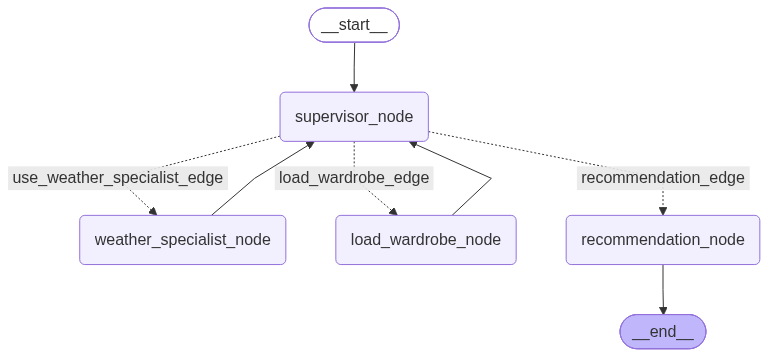

{'request': 'What is the weather today? Reply in one sentence.', 'weather_request': '', 'weather': '', 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}
weather_request='What is the current weather today?' wardrobe_request='' recommendation=''
{'request': 'What is the weather today? Reply in one sentence.', 'weather_request': '', 'weather': "I'd be happy to help you with current weather information! However, I need a bit more detail to provide an accurate assessment.\n\n**Could you please tell me:**\n- 📍 **What location** you'd like the weather for? (city, region, or zip code)\n\nOnce I know the location, I'll provide:\n\n1. **Current conditions** – temperature, precipitation, wind, and humidity\n2. **Clothing recommendations** – what to wear based on the conditions (layers, outerwear, footwear, accessories like umbrellas or sunglasses)\n3. **Any relevant alerts** – if there's anything notable like extreme heat, cold, or storms\n\nJust let me know the location and I'll get 

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file

class AgentState(TypedDict):
    request: str # the user request
    weather_request: str # filled by the supervisor if a weather request is needed
    weather: str # the answer from the weather specialist
    wardrobe_request : str # filled by the supervisor if a wardrobe is needed
    wardrobe: str # stores wardrobe.md after loading in
    recommendation: str # final output of the supervisor

# The following class allows for a structured output of the model towards the AgentState parameters
from pydantic import BaseModel, Field 
import json # used in supervisor function

class SupervisorDecision(BaseModel): # define the parameters for the structured output
    """Decision and output produced by the supervisor."""

    weather_request: str = Field(
        description=(
            "Weather information that is still needed. "
            "Include the location and the relevant forecast request. "
            "Return an empty string if no weather information is needed."
        )
    )

    wardrobe_request: str = Field(
        description=(
            "Indicate whether the wardrobe is still needed. "
            "Return a short request if the wardrobe is needed; "
            "otherwise return an empty string."
        )
    )

    recommendation: str = Field(
        description=(
            "The final clothing recommendation based on the user request, "
            "available weather information, and wardrobe. "
            "Return an empty string if the recommendation cannot yet be made."
        )
    )

# prepare llm: ensure a structured output as above for the supervisor
base_llm = ChatAnthropic(model="claude-sonnet-5")

supervisor_llm = base_llm.with_structured_output(
    SupervisorDecision,
    method="json_schema", # format of the structured output
)
# weather specialist does not need any specifications
weather_llm = base_llm


# define the nodes: supervisor, weather specialist, load wardrobe, recommendation
def supervisor(state:AgentState) -> AgentState:
    instructions = """
    You are the supervisor responsible for producing a final clothing recommendation.

    You can use:
    1. a weather specialist to obtain and interpret weather information
    2. the user's wardrobe stored in the state

    Your task is to inspect the CURRENT STATE and decide what information is still needed.

    Rules:
    - If weather information is required, populate weather_request with a concrete weather request.
    - If the wardrobe is required, populate wardrobe_request with a short request.
    - If no additional information is needed, leave the corresponding field empty.
    - Once enough information is available, produce the final clothing recommendation in recommendation.
    - If recommendation cannot be produced because required information is missing, write something to that in it.
    - Do not invent weather information or wardrobe items. If the weather specialist has no access to current data, work with what is returned.
    - Your response must follow the defined structured output schema.

    CURRENT STATE:
    """
    # append current state in json formatted string
    prompt = instructions + "\n" + json.dumps(
        state,
        ensure_ascii=False,
        indent=2
    )
    print(state)
    decision = supervisor_llm.invoke(prompt) # structured output like weather_request='What is the current weather today in Berlin?' wardrobe_request="Please provide the user's available wardrobe items." recommendation=''
    print(decision)
    return decision.model_dump() # returns already suitable state update format

def weather_specialist(state:AgentState) -> AgentState:
        system_prompt = (
        "You are a weather specialist agent. "
        "Obtain current weather information for the requested location, "
        "interpret it in terms relevant to clothing, and return a concise assessment."
        )

        response = weather_llm.invoke(system_prompt + "\n\nWeather request:\n" + state["weather_request"]) # is AIMessage so need .text below
        return {"weather": response.text, "weather_request": "",} # reset weather_request to empty string such that the router skips it in the next iteration, unless the supervisor fills it in again because it decides that another request is needed. 

def load_wardrobe(state: AgentState) -> AgentState:

    with open("wardrobe.md", "r", encoding="utf-8") as f:
        wardrobe = f.read()

    return {"wardrobe": wardrobe, "wardrobe_request": "",} # reset wardrobe_request

def recommend_answer(state:AgentState) -> AgentState:
    print("\nRecommendation:")
    print(state["recommendation"])
    return state


# the deterministic router logic: checking wether a weather or wardrobe request is submitted, else routing to the recommendation
def router(state:AgentState):
     if state["weather_request"]:
          return "use_weather_specialist_edge"
     elif state["wardrobe_request"]:
          return "load_wardrobe_edge"
     else:
          return "recommendation_edge"


# defining the graph structure, see picture below
graph = StateGraph(AgentState)
graph.add_node("supervisor_node", supervisor)
graph.add_node("weather_specialist_node", weather_specialist)
graph.add_node("load_wardrobe_node", load_wardrobe)
graph.add_node("recommendation_node", recommend_answer)

graph.set_entry_point("supervisor_node")
graph.add_conditional_edges(
    "supervisor_node",
    router,
    {
        "use_weather_specialist_edge": "weather_specialist_node",
        "recommendation_edge": "recommendation_node",
        "load_wardrobe_edge": "load_wardrobe_node",
    },
)
graph.add_edge("weather_specialist_node", "supervisor_node")
graph.add_edge("load_wardrobe_node", "supervisor_node")
graph.add_edge("recommendation_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


# Testing the agent with two documented trials below. Do not get confused by the printed intermediate states and the fact that the weather specialist has no access yet. 
answer = agent.invoke({"request": "What is the weather today? Reply in one sentence.", "weather_request": "", "weather": "", "wardrobe_request": "", "wardrobe": "", "recommendation": "",})
print(answer)


#{'request': 'What is the weather today in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': '', 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}
#weather_request='What is the current weather today in Berlin, including temperature, precipitation, and wind conditions?' wardrobe_request="Please provide the user's available wardrobe items." recommendation=''
#{'request': 'What is the weather today in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': '# Weather Assessment Request: Berlin\n\nI don\'t have access to real-time weather data or live internet feeds, so I can\'t pull the actual current conditions for Berlin today. I want to flag that clearly rather than guess and present it as fact.\n\n**To get accurate, current conditions, I\'d recommend:**\n- **Deutscher Wetterdienst (DWD)** – dwd.de (Germany\'s official weather service)\n- **weather.com** or **Google** (search "weather Berlin")\n- A weather app (Apple Weather, AccuWeather, Windy)\n\n---\n\n### What I *can* help with:\nIf you provide me the current readings (temperature, precipitation %, wind speed), I\'ll translate them into practical clothing guidance. For example, tell me something like:\n\n> "12°C, light rain, 20 km/h wind"\n\nAnd I\'ll respond with something like:\n\n> **Assessment:** Cool and damp — wear a waterproof jacket, a light sweater underneath, and closed shoes. Moderate wind means a hood or hat is useful; umbrella optional given the wind.\n\n---\n\nWould you like to share the current readings, or should I give you general seasonal guidance for Berlin based on the time of year?', 'wardrobe_request': "Please provide the user's available wardrobe items.", 'wardrobe': '', 'recommendation': ''}
#weather_request='' wardrobe_request="Please provide the user's available wardrobe items." recommendation=''
#{'request': 'What is the weather today in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': '# Weather Assessment Request: Berlin\n\nI don\'t have access to real-time weather data or live internet feeds, so I can\'t pull the actual current conditions for Berlin today. I want to flag that clearly rather than guess and present it as fact.\n\n**To get accurate, current conditions, I\'d recommend:**\n- **Deutscher Wetterdienst (DWD)** – dwd.de (Germany\'s official weather service)\n- **weather.com** or **Google** (search "weather Berlin")\n- A weather app (Apple Weather, AccuWeather, Windy)\n\n---\n\n### What I *can* help with:\nIf you provide me the current readings (temperature, precipitation %, wind speed), I\'ll translate them into practical clothing guidance. For example, tell me something like:\n\n> "12°C, light rain, 20 km/h wind"\n\nAnd I\'ll respond with something like:\n\n> **Assessment:** Cool and damp — wear a waterproof jacket, a light sweater underneath, and closed shoes. Moderate wind means a hood or hat is useful; umbrella optional given the wind.\n\n---\n\nWould you like to share the current readings, or should I give you general seasonal guidance for Berlin based on the time of year?', 'wardrobe_request': '', 'wardrobe': '# My Wardrobe\n\n### Tops:\n- T-shirts:\n    - petrol with print\n    - light blue with vintage-style print\n    - gray and black striped\n    - turquoise bottom, black top\n    - black with print\n    - turquoise with print\n    - light blue with print\n    - black with print\n    - heather gray\n    - heather gray-green\n    - White with print on the back\n    - Rust red, solid\n    - White, printed\n    - Green, solid\n    - Blue, solid\n    - Blue heather, solid\n    - Blue, printed\n    - Dark blue, solid\n    - White, printed\n    - Petrol, subtle print\n    - Light blue polo shirt\n    - Orange polo shirt with subtle stripes\n- Sweaters:\n    - Blue\n    - Ochre\n    - Orange\n    - Blue fleece\n    - Green, loose fit\n    - Black sweatshirt jacket\n\n### Pants:\n- Long:\n    - Light blue skinny jeans\n    - Blue straight-leg jeans\n    - Light brown chinos\n    - Black chinos\n    - White linen pants with a slight grayish tint\n    - White linen pants with a slight brownish tint\n- Shorts:\n    - Ochre\n    - Green linen pants\n    - Blue and white with fine vertical stripes\n    - Dark blue with white vertical stripes\n    - Dark green\n    - Dark gray', 'recommendation': ''}
#weather_request='' wardrobe_request='' recommendation="I wasn't able to get Berlin's actual current conditions from the weather service, so here's a safe, flexible option from your wardrobe: wear the heather gray T-shirt with the black chinos, and bring along the blue fleece sweater to layer on if it's cooler or breezy — this combo works well across a range of mild-to-cool temperatures typical for Berlin, and you can easily adjust by adding or removing the fleece depending on the actual weather you encounter."
#
#Recommendation:
#I wasn't able to get Berlin's actual current conditions from the weather service, so here's a safe, flexible option from your wardrobe: wear the heather gray T-shirt with the black chinos, and bring along the blue fleece sweater to layer on if it's cooler or breezy — this combo works well across a range of mild-to-cool temperatures typical for Berlin, and you can easily adjust by adding or removing the fleece depending on the actual weather you encounter.
#{'request': 'What is the weather today in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': '# Weather Assessment Request: Berlin\n\nI don\'t have access to real-time weather data or live internet feeds, so I can\'t pull the actual current conditions for Berlin today. I want to flag that clearly rather than guess and present it as fact.\n\n**To get accurate, current conditions, I\'d recommend:**\n- **Deutscher Wetterdienst (DWD)** – dwd.de (Germany\'s official weather service)\n- **weather.com** or **Google** (search "weather Berlin")\n- A weather app (Apple Weather, AccuWeather, Windy)\n\n---\n\n### What I *can* help with:\nIf you provide me the current readings (temperature, precipitation %, wind speed), I\'ll translate them into practical clothing guidance. For example, tell me something like:\n\n> "12°C, light rain, 20 km/h wind"\n\nAnd I\'ll respond with something like:\n\n> **Assessment:** Cool and damp — wear a waterproof jacket, a light sweater underneath, and closed shoes. Moderate wind means a hood or hat is useful; umbrella optional given the wind.\n\n---\n\nWould you like to share the current readings, or should I give you general seasonal guidance for Berlin based on the time of year?', 'wardrobe_request': '', 'wardrobe': '# My Wardrobe\n\n### Tops:\n- T-shirts:\n    - petrol with print\n    - light blue with vintage-style print\n    - gray and black striped\n    - turquoise bottom, black top\n    - black with print\n    - turquoise with print\n    - light blue with print\n    - black with print\n    - heather gray\n    - heather gray-green\n    - White with print on the back\n    - Rust red, solid\n    - White, printed\n    - Green, solid\n    - Blue, solid\n    - Blue heather, solid\n    - Blue, printed\n    - Dark blue, solid\n    - White, printed\n    - Petrol, subtle print\n    - Light blue polo shirt\n    - Orange polo shirt with subtle stripes\n- Sweaters:\n    - Blue\n    - Ochre\n    - Orange\n    - Blue fleece\n    - Green, loose fit\n    - Black sweatshirt jacket\n\n### Pants:\n- Long:\n    - Light blue skinny jeans\n    - Blue straight-leg jeans\n    - Light brown chinos\n    - Black chinos\n    - White linen pants with a slight grayish tint\n    - White linen pants with a slight brownish tint\n- Shorts:\n    - Ochre\n    - Green linen pants\n    - Blue and white with fine vertical stripes\n    - Dark blue with white vertical stripes\n    - Dark green\n    - Dark gray', 'recommendation': "I wasn't able to get Berlin's actual current conditions from the weather service, so here's a safe, flexible option from your wardrobe: wear the heather gray T-shirt with the black chinos, and bring along the blue fleece sweater to layer on if it's cooler or breezy — this combo works well across a range of mild-to-cool temperatures typical for Berlin, and you can easily adjust by adding or removing the fleece depending on the actual weather you encounter."}

#{'request': 'What is the weather today? Reply in one sentence.', 'weather_request': '', 'weather': '', 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}
#weather_request='What is the current weather today?' wardrobe_request='' recommendation=''
#{'request': 'What is the weather today? Reply in one sentence.', 'weather_request': '', 'weather': "I'd be happy to help you with current weather information! However, I need a bit more detail to provide an accurate assessment.\n\n**Could you please tell me:**\n- 📍 **What location** you'd like the weather for? (city, region, or zip code)\n\nOnce I know the location, I'll provide:\n\n1. **Current conditions** – temperature, precipitation, wind, and humidity\n2. **Clothing recommendations** – what to wear based on the conditions (layers, outerwear, footwear, accessories like umbrellas or sunglasses)\n3. **Any relevant alerts** – if there's anything notable like extreme heat, cold, or storms\n\nJust let me know the location and I'll get you sorted! 🌤️", 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}
#weather_request='' wardrobe_request='' recommendation=''
#
#Recommendation:
#
#{'request': 'What is the weather today? Reply in one sentence.', 'weather_request': '', 'weather': "I'd be happy to help you with current weather information! However, I need a bit more detail to provide an accurate assessment.\n\n**Could you please tell me:**\n- 📍 **What location** you'd like the weather for? (city, region, or zip code)\n\nOnce I know the location, I'll provide:\n\n1. **Current conditions** – temperature, precipitation, wind, and humidity\n2. **Clothing recommendations** – what to wear based on the conditions (layers, outerwear, footwear, accessories like umbrellas or sunglasses)\n3. **Any relevant alerts** – if there's anything notable like extreme heat, cold, or storms\n\nJust let me know the location and I'll get you sorted! 🌤️", 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}

## Integrating an API
As seen above, the graph routing remains explicitly controlled by the developer-defined structure. And even the capabilities are directly implemented inside developer-defined nodes. The following part integrates an explicit Open-Meteo API call inside the weather specialist agent node. Again, the developer designs the environment and the agent navigates it.

And in fact, the weather specialist doesn't even need a memory: The developer simulates this by stringing together prompts and given state parameters. This way, the agent knows immediately whether it is in the first step of the task (extracting the city and date for the forecast) or in the second step of the task (interpreting weather data). 

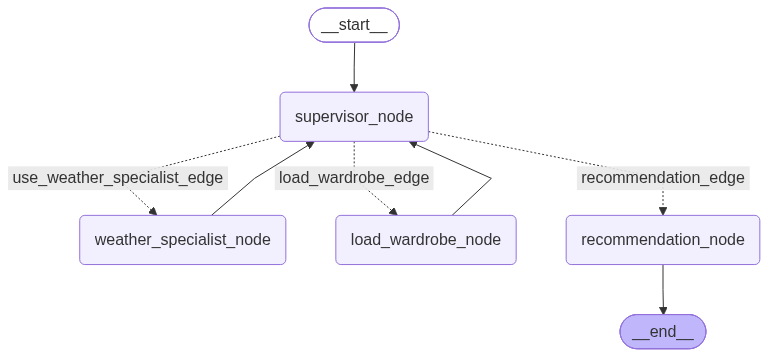

{'request': 'What is the weather today, october second 2026, in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': '', 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}
weather_request='What is the weather forecast for Berlin on October 2, 2026? Please reply in one sentence.' wardrobe_request="What clothing items are available in the user's wardrobe?" recommendation=''
Weather API request: city='Berlin' date='2026-10-02'
Forecast: {'location': 'Berlin, Germany', 'date': '2026-10-02', 'temperatureC': {'min': 12.2, 'max': 17.0}, 'precipitation': {'probabilityPercent': 30, 'totalMm': 0.1}, 'maxWindKmh': 10.0, 'weatherCode': 61}
{'request': 'What is the weather today, october second 2026, in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': 'On October 2, 2026, Berlin will see mild temperatures between 12–17°C with light rain likely (30% chance), so wear layers and bring a light rain jacket or umbrella.', 'wardrobe_request': "What clothing items

In [ ]:
from typing import TypedDict, Annotated, Sequence # Annotated provides context without affecting the type itself; Sequence automatically handles the state updates for sequences such as by adding new messages to the chat history
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage # BM: foundational class for all types in LangGraph (Parent class of AIMessage, HumanMessage, ToolMessage,...); TM: Passes data back to LLM after it calls a tool; SM: Providing instructions to LLM
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # Reducer function: Rule that controls how updates from nodes are combined with the existing state, i.e. tells us how to merge new data into the current state instead of replacing value entirely
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv

load_dotenv(override=True)  # Force loading environment variables from .env file
base_llm = ChatAnthropic(model="claude-sonnet-5") # using the model as base for all three necessary calls, see below

class AgentState(TypedDict):
    request: str # the user request
    weather_request: str # filled by the supervisor if a weather request is needed
    weather: str # the answer from the weather specialist
    wardrobe_request : str # filled by the supervisor if a wardrobe is needed
    wardrobe: str # stores wardrobe.md after loading in
    recommendation: str # final output of the supervisor




# The following class allows for a structured output of the model towards the AgentState parameters
from pydantic import BaseModel, Field 
import json # used in supervisor function

class SupervisorDecision(BaseModel): # define the parameters for the structured output
    """Decision and output produced by the supervisor."""

    weather_request: str = Field(
        description=(
            "Weather information that is still needed. "
            "Include the location and the relevant forecast request. "
            "Return an empty string if no weather information is needed."
        )
    )

    wardrobe_request: str = Field(
        description=(
            "Indicate whether the wardrobe is still needed. "
            "Return a short request if the wardrobe is needed; "
            "otherwise return an empty string."
        )
    )

    recommendation: str = Field(
        description=(
            "The final clothing recommendation based on the user request, "
            "available weather information, and wardrobe. "
            "Return an empty string if the recommendation cannot yet be made."
        )
    )

# prepare llm: ensure a structured output as above for the supervisor
supervisor_llm = base_llm.with_structured_output(
    SupervisorDecision,
    method="json_schema", # format of the structured output
)

# define supervisor node as before
def supervisor(state:AgentState) -> AgentState:
    instructions = """
    You are the supervisor responsible for producing a final clothing recommendation.

    You can use:
    1. a weather specialist to obtain and interpret weather information
    2. the user's wardrobe stored in the state

    Your task is to inspect the CURRENT STATE and decide what information is still needed.

    Rules:
    - If weather information is required, populate weather_request with a concrete weather request.
    - If the wardrobe is required, populate wardrobe_request with a short request.
    - If no additional information is needed, leave the corresponding field empty.
    - Once enough information is available, produce the final clothing recommendation in recommendation.
    - If recommendation cannot be produced because required information is missing, write something to that in it.
    - Do not invent weather information or wardrobe items. If the weather specialist has no access to current data, work with what is returned.
    - Your response must follow the defined structured output schema.

    CURRENT STATE:
    """
    # append current state in json formatted string
    prompt = instructions + "\n" + json.dumps(
        state,
        ensure_ascii=False,
        indent=2
    )
    print(state)
    decision = supervisor_llm.invoke(prompt) # structured output like weather_request='What is the current weather today in Berlin?' wardrobe_request="Please provide the user's available wardrobe items." recommendation=''
    print(decision)
    return decision.model_dump()






# The actual http request function calling free Open-Meteo API once for geocoding and then for the weather data
import httpx
def get_forecast(city: str, date: str) -> dict:
    """Get a daily weather forecast from Open-Meteo."""

    geocoding_response = httpx.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={
            "name": city,
            "count": 1,
            "language": "en",
            "format": "json",
        },
        timeout=10,
    )
    geocoding_response.raise_for_status()

    places = geocoding_response.json()
    place = places.get("results", [None])[0]

    if not place:
        raise ValueError(f"Could not find a location for {city}.")

    forecast_response = httpx.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": place["latitude"],
            "longitude": place["longitude"],
            "daily": ",".join([
                "weather_code",
                "temperature_2m_max",
                "temperature_2m_min",
                "precipitation_probability_max",
                "precipitation_sum",
                "wind_speed_10m_max",
            ]),
            "timezone": "auto",
            "start_date": date,
            "end_date": date,
        },
        timeout=10,
    )
    forecast_response.raise_for_status()

    daily = forecast_response.json()["daily"]

    return {
        "location": f'{place["name"]}, {place["country"]}',
        "date": date,
        "temperatureC": {
            "min": daily["temperature_2m_min"][0],
            "max": daily["temperature_2m_max"][0],
        },
        "precipitation": {
            "probabilityPercent": daily["precipitation_probability_max"][0],
            "totalMm": daily["precipitation_sum"][0],
        },
        "maxWindKmh": daily["wind_speed_10m_max"][0],
        "weatherCode": daily["weather_code"][0],
    }



## For a structured output of the weather_specialist's first LLM call extracting city and date from the request.
class WeatherRequest(BaseModel):
    """Parameters required to request weather data."""

    city: str = Field(
        description="The city for which the weather forecast is needed."
    )

    date: str = Field(
        description="The date of the forecast in YYYY-MM-DD format."
    )

# prepare llm: ensure a structured output as above for the first LLM call of the weather_specialist while the second one does not require any formatting, hence the plain base_llm is used there
weather_request_llm = base_llm.with_structured_output(
    WeatherRequest,
    method="json_schema",
)
weather_llm = base_llm


# The weather specialist node: 
# - calling an llm to extract city and date from the supervisors's weather request
# - calling the API via the above get_forecast function, no llm needed
# - calling an llm again to interpret the forecast
def weather_specialist(state:AgentState) -> AgentState:
    system_prompt = """
    You are a weather specialist agent.

    The supervisor asks you to obtain and interpret weather information.

    First, extract the city and date (in YYYY-MM-DD format) required for the weather request.
    Then use the provided forecast data to produce a concise weather assessment
    relevant to clothing.

    Do not invent weather data.
    """

    # LLM call 1: extract API parameters
    request_prompt = (
        system_prompt
        + "\n\nWEATHER REQUEST:\n"
        + state["weather_request"]
    )

    weather_city_date = weather_request_llm.invoke(request_prompt)

    print("Weather API request:", weather_city_date)

    # API call 

    forecast = get_forecast(
        weather_city_date.city,
        weather_city_date.date,
    )

    print("Forecast:", forecast)

    # LLM call 2: interpret forecast

    interpretation_prompt = (
        system_prompt
        + "\n\nWEATHER REQUEST:\n"
        + state["weather_request"]
        + "\n\nFORECAST DATA:\n"
        + str(forecast)
        + "\n\nProvide the concise weather assessment for the supervisor."
    )

    response = weather_llm.invoke(interpretation_prompt)

    return {"weather": response.text, "weather_request": "",}



# the other nodes, router and graph strucutre are just as before
def load_wardrobe(state: AgentState) -> AgentState:

    with open("wardrobe.md", "r", encoding="utf-8") as f:
        wardrobe = f.read()

    return {"wardrobe": wardrobe, "wardrobe_request": "",}

def recommend_answer(state:AgentState) -> AgentState:
    print("\nRecommendation:")
    print(state["recommendation"])
    return state


def router(state:AgentState):
     if state["weather_request"]:
          return "use_weather_specialist_edge"
     elif state["wardrobe_request"]:
          return "load_wardrobe_edge"
     else:
          return "recommendation_edge"


graph = StateGraph(AgentState)
graph.add_node("supervisor_node", supervisor)
graph.add_node("weather_specialist_node", weather_specialist)
graph.add_node("load_wardrobe_node", load_wardrobe)
graph.add_node("recommendation_node", recommend_answer)

graph.set_entry_point("supervisor_node")
graph.add_conditional_edges(
    "supervisor_node",
    router,
    {
        "use_weather_specialist_edge": "weather_specialist_node",
        "recommendation_edge": "recommendation_node",
        "load_wardrobe_edge": "load_wardrobe_node",
    },
)
graph.add_edge("weather_specialist_node", "supervisor_node")
graph.add_edge("load_wardrobe_node", "supervisor_node")
graph.add_edge("recommendation_node", END)

agent = graph.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


# Testing the workflow: the weather API worked as intended. But be careful: if the supervisor's request does not contain city and date but still delegates to the weather specialist, there probably will be an error since no exit is implemented.
answer = agent.invoke({"request": "What is the weather today, october second 2026, in Berlin? Reply in one sentence.", "weather_request": "", "weather": "", "wardrobe_request": "", "wardrobe": "", "recommendation": "",})
print(answer)

#{'request': 'What is the weather today, october second 2026, in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': '', 'wardrobe_request': '', 'wardrobe': '', 'recommendation': ''}
#weather_request='What is the weather forecast for Berlin on October 2, 2026? Please reply in one sentence.' wardrobe_request="What clothing items are available in the user's wardrobe?" recommendation=''
#Weather API request: city='Berlin' date='2026-10-02'
#Forecast: {'location': 'Berlin, Germany', 'date': '2026-10-02', 'temperatureC': {'min': 12.2, 'max': 17.0}, 'precipitation': {'probabilityPercent': 30, 'totalMm': 0.1}, 'maxWindKmh': 10.0, 'weatherCode': 61}
#{'request': 'What is the weather today, october second 2026, in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': 'On October 2, 2026, Berlin will see mild temperatures between 12–17°C with light rain likely (30% chance), so wear layers and bring a light rain jacket or umbrella.', 'wardrobe_request': "What clothing items are available in the user's wardrobe?", 'wardrobe': '', 'recommendation': ''}
#weather_request='' wardrobe_request="What clothing items are available in the user's wardrobe?" recommendation=''
#{'request': 'What is the weather today, october second 2026, in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': 'On October 2, 2026, Berlin will see mild temperatures between 12–17°C with light rain likely (30% chance), so wear layers and bring a light rain jacket or umbrella.', 'wardrobe_request': '', 'wardrobe': '# My Wardrobe\n\n### Tops:\n- T-shirts:\n    - petrol with print\n    - light blue with vintage-style print\n    - gray and black striped\n    - turquoise bottom, black top\n    - black with print\n    - turquoise with print\n    - light blue with print\n    - black with print\n    - heather gray\n    - heather gray-green\n    - White with print on the back\n    - Rust red, solid\n    - White, printed\n    - Green, solid\n    - Blue, solid\n    - Blue heather, solid\n    - Blue, printed\n    - Dark blue, solid\n    - White, printed\n    - Petrol, subtle print\n    - Light blue polo shirt\n    - Orange polo shirt with subtle stripes\n- Sweaters:\n    - Blue\n    - Ochre\n    - Orange\n    - Blue fleece\n    - Green, loose fit\n    - Black sweatshirt jacket\n\n### Pants:\n- Long:\n    - Light blue skinny jeans\n    - Blue straight-leg jeans\n    - Light brown chinos\n    - Black chinos\n    - White linen pants with a slight grayish tint\n    - White linen pants with a slight brownish tint\n- Shorts:\n    - Ochre\n    - Green linen pants\n    - Blue and white with fine vertical stripes\n    - Dark blue with white vertical stripes\n    - Dark green\n    - Dark gray', 'recommendation': ''}
#weather_request='' wardrobe_request='' recommendation="For October 2, 2026 in Berlin (mild 12–17°C with a 30% chance of light rain), dress in layers: pick a t-shirt (e.g., the heather gray or blue solid one), add a sweater such as the blue or ochre one for warmth, and top it with your black sweatshirt jacket to help block wind and light rain since you don't have a dedicated rain jacket. Pair this with long pants like the black chinos or blue straight-leg jeans for comfort and weather protection, and consider carrying an umbrella since no raincoat is available in your wardrobe."
#
#Recommendation:
#For October 2, 2026 in Berlin (mild 12–17°C with a 30% chance of light rain), dress in layers: pick a t-shirt (e.g., the heather gray or blue solid one), add a sweater such as the blue or ochre one for warmth, and top it with your black sweatshirt jacket to help block wind and light rain since you don't have a dedicated rain jacket. Pair this with long pants like the black chinos or blue straight-leg jeans for comfort and weather protection, and consider carrying an umbrella since no raincoat is available in your wardrobe.
#{'request': 'What is the weather today, october second 2026, in Berlin? Reply in one sentence.', 'weather_request': '', 'weather': 'On October 2, 2026, Berlin will see mild temperatures between 12–17°C with light rain likely (30% chance), so wear layers and bring a light rain jacket or umbrella.', 'wardrobe_request': '', 'wardrobe': '# My Wardrobe\n\n### Tops:\n- T-shirts:\n    - petrol with print\n    - light blue with vintage-style print\n    - gray and black striped\n    - turquoise bottom, black top\n    - black with print\n    - turquoise with print\n    - light blue with print\n    - black with print\n    - heather gray\n    - heather gray-green\n    - White with print on the back\n    - Rust red, solid\n    - White, printed\n    - Green, solid\n    - Blue, solid\n    - Blue heather, solid\n    - Blue, printed\n    - Dark blue, solid\n    - White, printed\n    - Petrol, subtle print\n    - Light blue polo shirt\n    - Orange polo shirt with subtle stripes\n- Sweaters:\n    - Blue\n    - Ochre\n    - Orange\n    - Blue fleece\n    - Green, loose fit\n    - Black sweatshirt jacket\n\n### Pants:\n- Long:\n    - Light blue skinny jeans\n    - Blue straight-leg jeans\n    - Light brown chinos\n    - Black chinos\n    - White linen pants with a slight grayish tint\n    - White linen pants with a slight brownish tint\n- Shorts:\n    - Ochre\n    - Green linen pants\n    - Blue and white with fine vertical stripes\n    - Dark blue with white vertical stripes\n    - Dark green\n    - Dark gray', 'recommendation': "For October 2, 2026 in Berlin (mild 12–17°C with a 30% chance of light rain), dress in layers: pick a t-shirt (e.g., the heather gray or blue solid one), add a sweater such as the blue or ochre one for warmth, and top it with your black sweatshirt jacket to help block wind and light rain since you don't have a dedicated rain jacket. Pair this with long pants like the black chinos or blue straight-leg jeans for comfort and weather protection, and consider carrying an umbrella since no raincoat is available in your wardrobe."}